# Forman Profile: evolution across training checkpoints

## 1. Imports

In [1]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp
from scipy.stats import spearmanr, pearsonr, wasserstein_distance

## 2. Utility functions

In [6]:
def compute_F_diags_from_coo(lap, n, d):
    """
    Forman-Bochner diagonal blocks F_{u,u} from a COO sheaf Laplacian.
    L = B + F, where B_{u,u} = sum_{v~u} |L_{u,v}|  (matrix absolute value via SVD)
    Returns: F_diags — np.ndarray (n, d, d)
    """
    row_idx = lap[0].long().numpy().astype(np.int64)
    col_idx = lap[1].long().numpy().astype(np.int64)
    values  = lap[2].numpy()

    block_row = row_idx // d
    block_col = col_idx // d
    local_r   = row_idx % d
    local_c   = col_idx % d
    is_diag   = (block_row == block_col)

    diag_blocks = np.zeros((n, d, d))
    dm = is_diag
    np.add.at(diag_blocks, (block_row[dm], local_r[dm], local_c[dm]), values[dm])

    off_mask = ~is_diag
    off_br, off_bc = block_row[off_mask], block_col[off_mask]
    off_lr, off_lc = local_r[off_mask],  local_c[off_mask]
    off_vals        = values[off_mask]

    block_ids = off_br * n + off_bc
    unique_ids, inverse = np.unique(block_ids, return_inverse=True)
    num_blocks = len(unique_ids)

    all_blocks = np.zeros((num_blocks, d, d))
    np.add.at(all_blocks, (inverse, off_lr, off_lc), off_vals)

    nonzero_mask = np.any(all_blocks != 0, axis=(1, 2))
    abs_blocks   = np.zeros_like(all_blocks)
    if np.any(nonzero_mask):
        nz = all_blocks[nonzero_mask]
        U, S, _ = np.linalg.svd(nz)
        abs_blocks[nonzero_mask] = np.einsum('bij,bj,bkj->bik', U, S, U)

    B_diag = np.zeros((n, d, d))
    unique_block_rows = (unique_ids // n).astype(np.int64)
    np.add.at(B_diag, unique_block_rows, abs_blocks)

    return diag_blocks - B_diag

## 3. Config

In [7]:
dataset         = "roman_empire"
model           = "GeneralSheaf"
Norm            = "true"
stalk_dim       = 5
layers          = 5
hidden_channels = 16
epochs          = 500
seed            = 43
#num_nodes       = 3327 # citeseer
# num_nodes = 183 # Cornell
num_nodes = 22662 # Roman Empire
#num_nodes = 10000 # minsesweeper
#num_nodes = 2708 # Cora
#num_nodes = 3327 # Citeseer 
#num_nodes = 19717 # Pubmed
#num_nodes = 183 # Cornell
#num_nodes = 500 # synthetic
#num_nodes      = 251  # Wisconsin
#num_nodes       = 24492 # Amazon Ratings
#num_nodes = 48921 # Questions
#num_nodes = 11758 # Tolokers
num_folds       = 10

mode             = "General"
learn_first_maps = False
lfm_tag = f"_learn_first_maps-{str(learn_first_maps).lower()}" if mode == "JointSheafParamsAlt" else ""

n, d = num_nodes, stalk_dim

# Checkpoints to analyse — order defines row order in the megaplot.
# 'last' refers to the top-level (final epoch) Laplacians, not a checkpoints/ subdir.
checkpoint_names = ['epoch-0', 'epoch-1', 'epoch-5', 'epoch-15', 'epoch-200', 'best-epoch', 'last']

BASE = (f"../results/laplacians/{dataset}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
        f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs")

def lap_path(layer, fold, ckpt_name):
    filename = f"{model}_{dataset}_layer{layer}_fold{fold}{lfm_tag}_seed{seed}.pt"
    if ckpt_name == 'last':
        return os.path.join(BASE, filename)
    return os.path.join(BASE, 'checkpoints', ckpt_name, filename)

# Load best_epochs.json if it exists.
# New format: {fold_k: {best_epoch, best_val_acc, best_test_acc, checkpoints: {ckpt_name: {train_acc, val_acc, test_acc}}}}
# Old format (fallback): {fold_k: int}
best_epochs_json = os.path.join(BASE, 'best_epochs.json')
best_epochs_data = {}
if os.path.exists(best_epochs_json):
    with open(best_epochs_json) as f:
        best_epochs_data = json.load(f)
    print(f"Loaded best_epochs.json ({len(best_epochs_data)} folds)")
else:
    print("best_epochs.json not found — row labels will have no accuracy annotation.")


def ckpt_acc_stats(ckpt_name):
    """Return (mean_test_acc, std_test_acc) across folds for a given checkpoint label, or (None, None)."""
    accs = []
    for fold_entry in best_epochs_data.values():
        if not isinstance(fold_entry, dict):
            return None, None   # old format — no accuracy data
        entry = fold_entry.get('checkpoints', {}).get(ckpt_name, {})
        acc = entry.get('test_acc')
        if acc is not None:
            accs.append(float(acc))
    if not accs:
        return None, None
    return float(np.mean(accs)), float(np.std(accs))

Loaded best_epochs.json (10 folds)


## 4. Topological reference

In [8]:
# Build the graph from any available Laplacian (use last-epoch fold 0 as reference).
ref_path = lap_path(layer=0, fold=0, ckpt_name='last')
if not os.path.exists(ref_path):
    # fall back to epoch-0 checkpoint if last not available
    ref_path = lap_path(layer=0, fold=0, ckpt_name='epoch-0')

lap0    = torch.load(ref_path, weights_only=True)
row_idx = lap0[0].long().numpy()
col_idx = lap0[1].long().numpy()

edges = set()
for r, c in zip(row_idx, col_idx):
    u, v = int(r) // d, int(c) // d
    if u != v:
        edges.add((min(u, v), max(u, v)))

G = nx.Graph()
G.add_nodes_from(range(n))
G.add_edges_from(sorted(edges))
print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

L_top_un   = nx.laplacian_matrix(G, nodelist=list(range(n))).astype(float)
degrees    = np.array(L_top_un.diagonal())
D_inv_sqrt = sp.diags(1.0 / np.sqrt(degrees + 1))
L_top_sp   = D_inv_sqrt @ L_top_un @ D_inv_sqrt

diag_vals    = np.array(L_top_sp.diagonal())
abs_row_sums = np.array(np.abs(L_top_sp).sum(axis=1)).ravel()
f0_top       = 2 * diag_vals - abs_row_sums
f0_norm      = (f0_top - f0_top.mean()) / f0_top.std()
print(f"f0_top range: [{f0_top.min():.3f}, {f0_top.max():.3f}]")

22662 nodes, 32927 edges
f0_top range: [-0.826, 0.259]


## 5. Compute metrics for every checkpoint

For each checkpoint we load all available folds, compute Forman eigenvalues, then compute Spearman ρ, Pearson r and Wasserstein distance vs the topological reference f0_top.

In [9]:
results = {}  # {ckpt_name: dict of arrays (layers, d)}

for ckpt_name in checkpoint_names:
    print(f"\n--- {ckpt_name} ---")
    # Collect eigenvalues per (fold, layer, node, eig_idx)
    buf = np.zeros((num_folds, layers, n, d))
    fold_ok = np.zeros(num_folds, dtype=bool)

    for fold in range(num_folds):
        ok = True
        for layer in range(layers):
            path = lap_path(layer, fold, ckpt_name)
            if not os.path.exists(path):
                ok = False
                break
            lap = torch.load(path, weights_only=True)
            F_diags = compute_F_diags_from_coo(lap, n, d)
            buf[fold, layer] = np.linalg.eigvalsh(F_diags)
        fold_ok[fold] = ok
        if ok:
            print(f"  fold {fold} done")
        else:
            print(f"  fold {fold} — file missing, skipped")

    available = buf[fold_ok]   # (n_avail, layers, n, d)
    n_avail   = fold_ok.sum()
    if n_avail == 0:
        print(f"  No folds available for {ckpt_name}, skipping.")
        continue

    sp_vals = np.zeros((n_avail, layers, d))
    pe_vals = np.zeros((n_avail, layers, d))
    wa_vals = np.zeros((n_avail, layers, d))

    for i in range(n_avail):
        for layer in range(layers):
            for k in range(d):
                c      = available[i, layer, :, k]
                c_norm = (c - c.mean()) / (c.std() + 1e-9)
                sp_vals[i, layer, k] = spearmanr(c, f0_top).statistic
                pe_vals[i, layer, k] = pearsonr(c, f0_top).statistic
                wa_vals[i, layer, k] = wasserstein_distance(c_norm, f0_norm)

    results[ckpt_name] = {
        'spearman_mean':    sp_vals.mean(axis=0),   # (layers, d)
        'spearman_std':     sp_vals.std(axis=0),
        'pearson_mean':     pe_vals.mean(axis=0),
        'pearson_std':      pe_vals.std(axis=0),
        'wasserstein_mean': wa_vals.mean(axis=0),
        'wasserstein_std':  wa_vals.std(axis=0),
        'n_folds':          n_avail,
    }
    print(f"  -> metrics computed on {n_avail} fold(s)")

print("\nDone. Available checkpoints:", list(results.keys()))


--- epoch-0 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> metrics computed on 10 fold(s)

--- epoch-1 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> metrics computed on 10 fold(s)

--- epoch-5 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> metrics computed on 10 fold(s)

--- epoch-15 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> metrics computed on 10 fold(s)

--- epoch-200 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> metrics computed on 10 fold(s)

--- best-epoch ---
  fold 0 don

## 6. Megaplot

Rows = checkpoints (epoch-0 → epoch-N → best-epoch → last).  
Columns = Spearman ρ · Pearson r · Wasserstein.  
Each subplot: metric vs layer, one line per eigenvalue index.

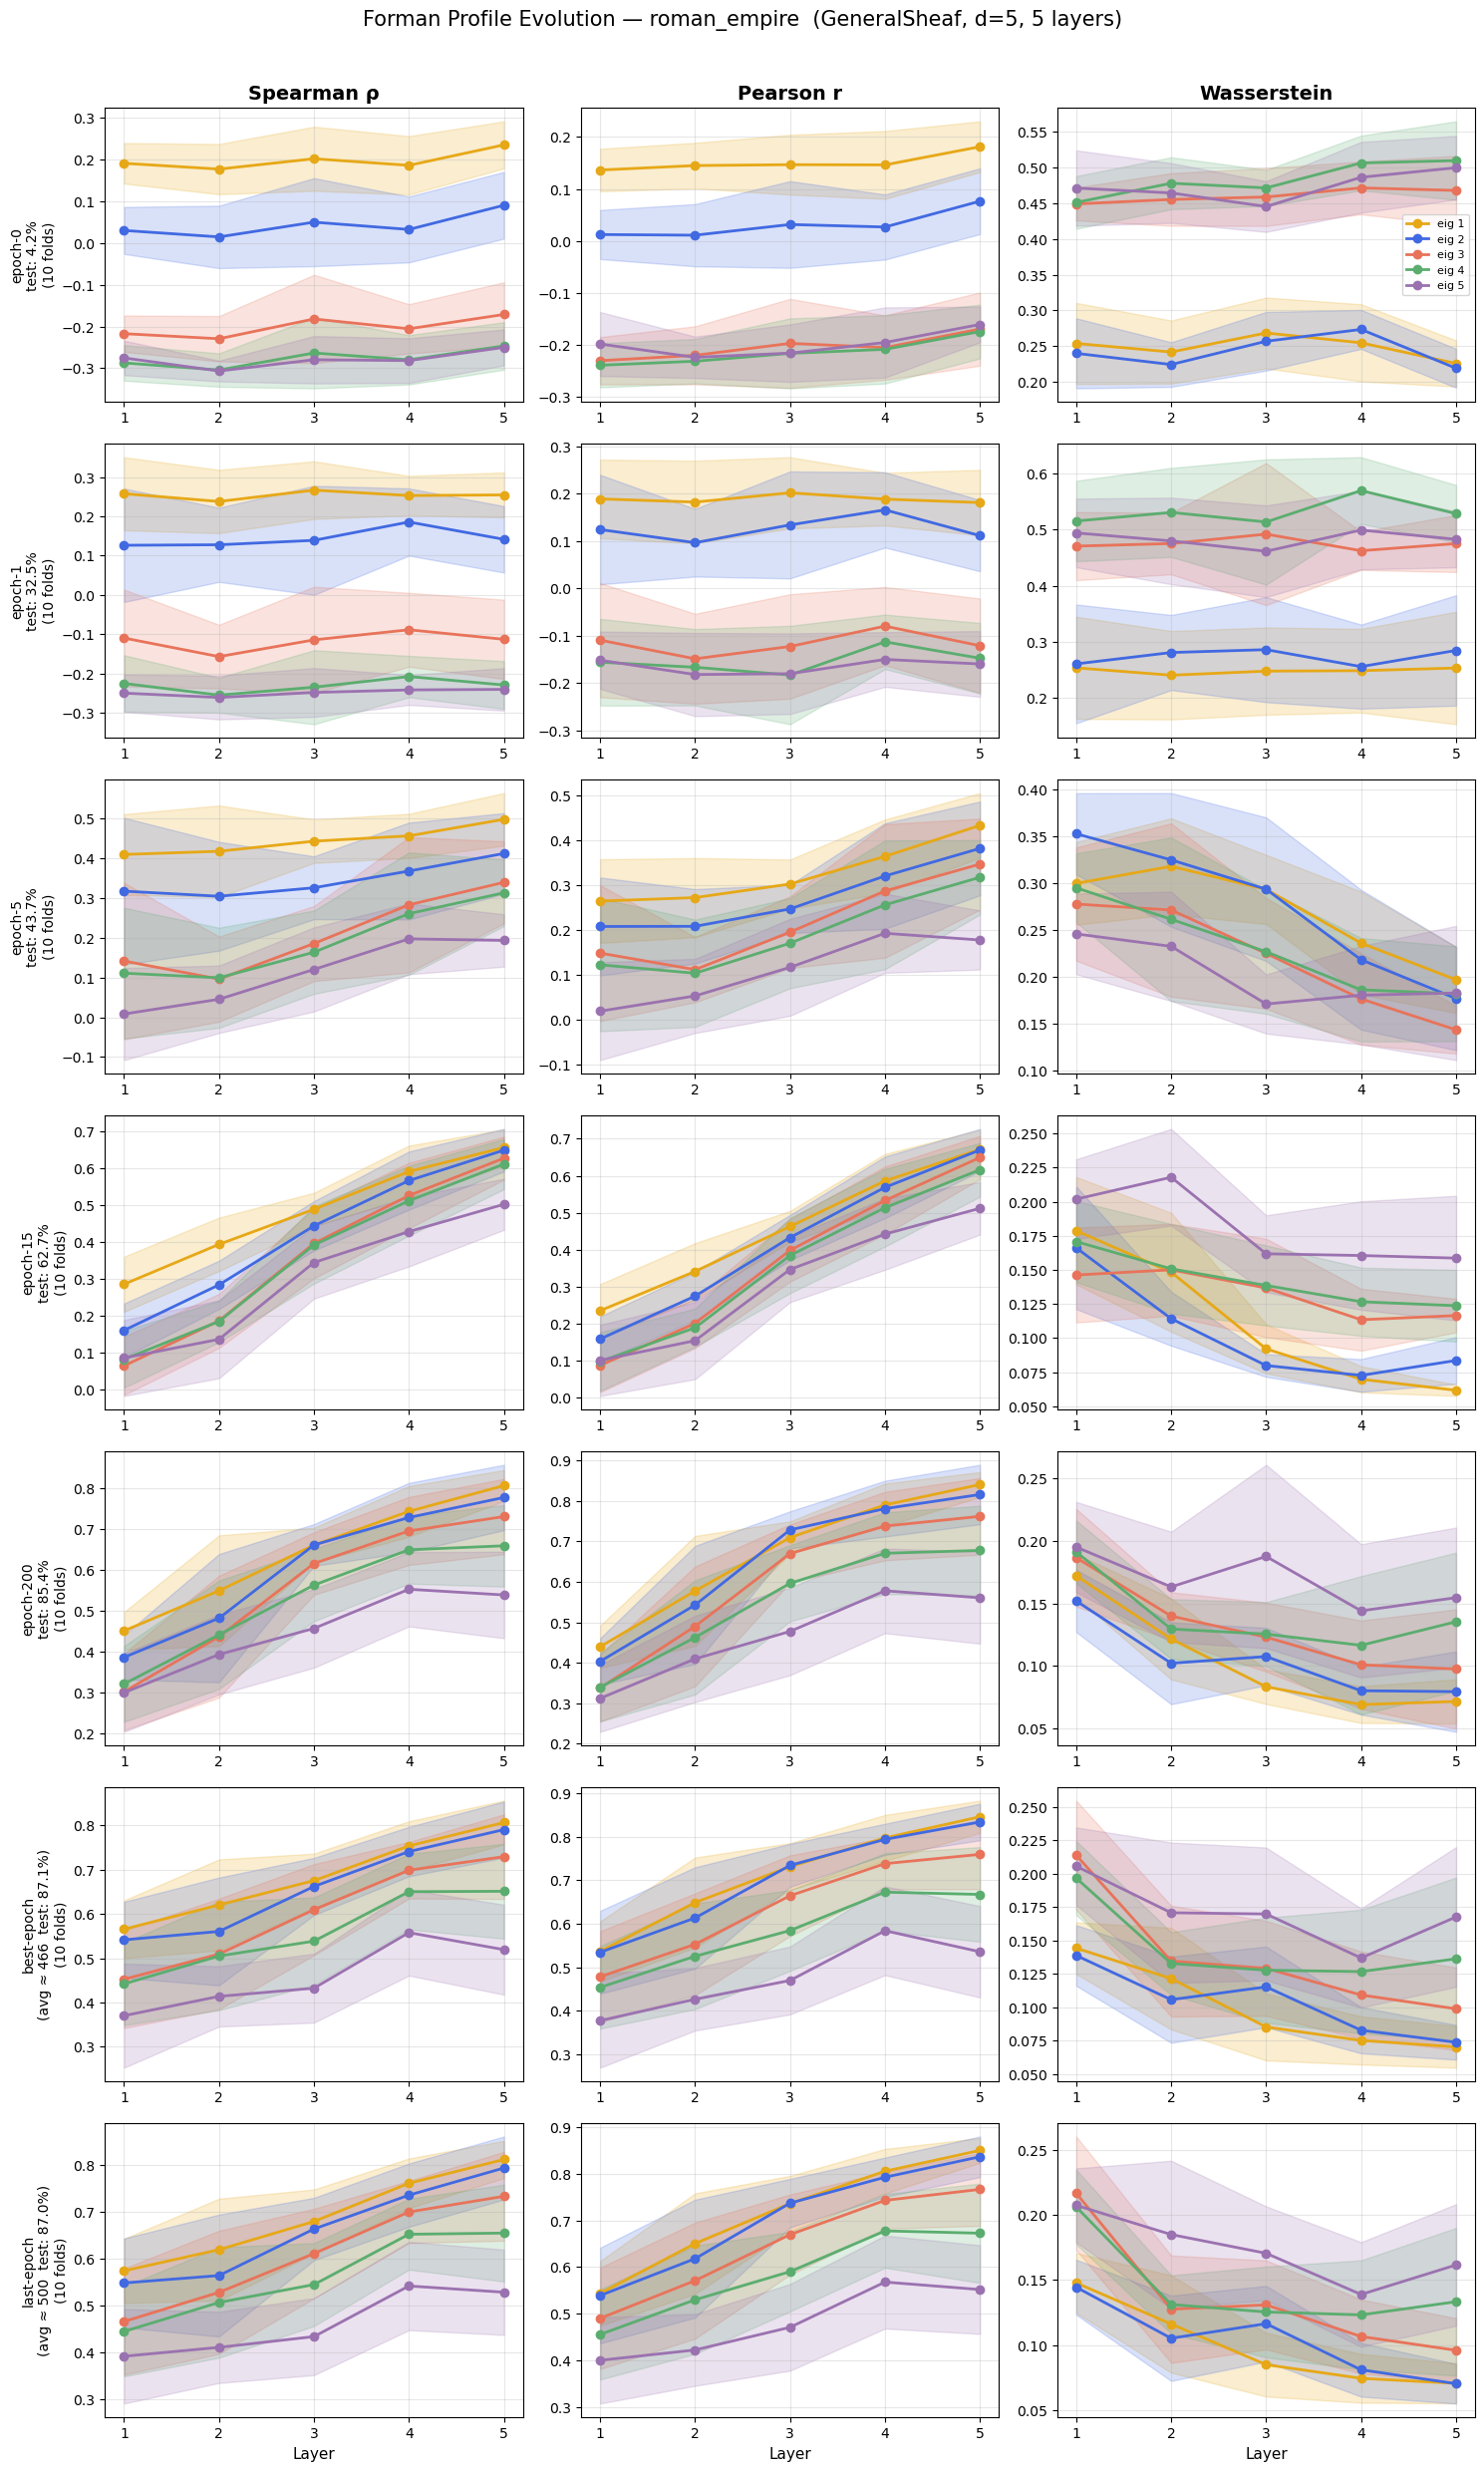

In [10]:
PALETTE = ["#E6A817", "#4169E1", "#E8735A", "#5BAD6F", "#9B72B0",
           "#5BB8C9", "#C97D4E", "#C75B8A"]
colors      = PALETTE[:d]
layer_ticks = np.arange(1, layers + 1)

valid = [c for c in checkpoint_names if c in results]
n_rows, n_cols = len(valid), 3

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 3.5 * n_rows),
                         squeeze=False)

metric_specs = [
    ('spearman_mean',    'spearman_std',    'Spearman ρ'),
    ('pearson_mean',     'pearson_std',     'Pearson r'),
    ('wasserstein_mean', 'wasserstein_std', 'Wasserstein'),
]

for row, ckpt_name in enumerate(valid):
    res = results[ckpt_name]
    n_avail = res['n_folds']

    # Build row label with test accuracy and (for best/last) epoch number annotation.
    avg_acc, _ = ckpt_acc_stats(ckpt_name)
    acc_str = f"  test: {avg_acc*100:.1f}%" if avg_acc is not None else ""

    if ckpt_name == 'best-epoch' and best_epochs_data:
        epoch_vals = []
        for fold_entry in best_epochs_data.values():
            if isinstance(fold_entry, dict):
                epoch_vals.append(fold_entry.get('best_epoch', float('nan')))
            else:
                epoch_vals.append(float(fold_entry))
        avg_best  = np.nanmean(epoch_vals) if epoch_vals else float('nan')
        row_label = f"best-epoch\n(avg ≈ {avg_best:.0f}{acc_str})"

    elif ckpt_name == 'last':
        epoch_vals = []
        for fold_entry in best_epochs_data.values():
            if isinstance(fold_entry, dict):
                ep = fold_entry.get('checkpoints', {}).get('last', {}).get('epoch')
                if ep is not None:
                    epoch_vals.append(float(ep) + 1)   # +1: stored index is 0-based
        if epoch_vals:
            avg_last  = np.nanmean(epoch_vals)
            row_label = f"last-epoch\n(avg ≈ {avg_last:.0f}{acc_str})"
        else:
            row_label = f"last-epoch{chr(10) + acc_str.strip() if acc_str else ''}"

    else:
        row_label = f"{ckpt_name}{chr(10) + acc_str.strip() if acc_str else ''}"

    for col, (mean_key, std_key, title) in enumerate(metric_specs):
        ax     = axes[row, col]
        mu_mat = res[mean_key]   # (layers, d)
        sg_mat = res[std_key]

        for k in range(d):
            mu  = mu_mat[:, k]
            sig = sg_mat[:, k]
            ax.plot(layer_ticks, mu, marker='o', color=colors[k],
                    label=f"eig {k+1}", lw=2)
            ax.fill_between(layer_ticks, mu - sig, mu + sig,
                            alpha=0.2, color=colors[k])

        ax.set_xticks(layer_ticks)
        ax.grid(alpha=0.3)

        if row == 0:
            ax.set_title(title, fontsize=14, fontweight='bold')
        if row == n_rows - 1:
            ax.set_xlabel("Layer", fontsize=11)
        if col == 0:
            ax.set_ylabel(f"{row_label}\n({n_avail} fold{'s' if n_avail > 1 else ''})",
                          fontsize=10)
        if row == 0 and col == n_cols - 1:
            ax.legend(fontsize=8, loc='best')

fig.suptitle(
    f"Forman Profile Evolution — {dataset}  ({model}, d={d}, {layers} layers)",
    fontsize=15, y=1.01
)
fig.tight_layout()
os.makedirs("metric_images", exist_ok=True)
plt.savefig(f"metric_images/{dataset}_{model}_d{d}_{layers}L_Norm_{Norm}_checkpoints_evolution.pdf", bbox_inches="tight")
plt.show()